<a href="https://colab.research.google.com/github/ruchira0011/Electricity-Demand-Forecasting-in-Great-Britain/blob/main/Uk_Energy_ARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Data

In [4]:
import pandas as pd

# List of NESO Historic Demand CSV URLs (you can extend this list)
urls = {
    2026: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/8a4a771c-3929-4e56-93ad-cdf13219dea5/download/demanddata_2026.csv",
    2025: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/b2bde559-3455-4021-b179-dfe60c0337b0/download/demanddata_2025.csv",
    2024: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/f6d02c0f-957b-48cb-82ee-09003f2ba759/download/demanddata_2024.csv",
    2023: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/bf5ab335-9b40-4ea4-b93a-ab4af7bce003/download/demanddata_2023.csv",
    2022: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/bb44a1b5-75b1-4db2-8491-257f23385006/download/demanddata_2022.csv",
    2021: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/18c69c42-f20d-46f0-84e9-e279045befc6/download/demanddata_2021.csv",
    2020: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/33ba6857-2a55-479f-9308-e5c4c53d4381/download/demanddata_2020.csv",
    2019: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/dd9de980-d724-415a-b344-d8ae11321432/download/demanddata_2019.csv",
    2018: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/fcb12133-0db0-4f27-a4a5-1669fd9f6d33/download/demanddata_2018.csv",
    2017: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/2f0f75b8-39c5-46ff-a914-ae38088ed022/download/demanddata_2017.csv",
    2016: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/3bb75a28-ab44-4a0b-9b1c-9be9715d3c44/download/demanddata_2016.csv",
    2015: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/cc505e45-65ae-4819-9b90-1fbb06880293/download/demanddata_2015.csv",
    2014: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/b9005225-49d3-40d1-921c-03ee2d83a2ff/download/demanddata_2014.csv",
    2013: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/2ff7aaff-8b42-4c1b-b234-9446573a1e27/download/demanddata_2013.csv",
    2012: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/4bf713a2-ea0c-44d3-a09a-63fc6a634b00/download/demanddata_2012.csv",
    2011: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/01522076-2691-4140-bfb8-c62284752efd/download/demanddata_2011.csv",
    2010: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/b3eae4a5-8c3c-4df1-b9de-7db243ac3a09/download/demanddata_2010.csv"
}

def load_neso_demand(urls: dict) -> pd.DataFrame:
    dfs = []
    for year, url in urls.items():
        print(f"Loading {year} data...")
        df_year = pd.read_csv(url)
        df_year["Year"] = year  # optional: keep track of source year
        dfs.append(df_year)
    return pd.concat(dfs, ignore_index=True)

df = load_neso_demand(urls)

print("Shape:", df.shape)
print(df.head())
print(df.columns)

Loading 2026 data...
Loading 2025 data...
Loading 2024 data...
Loading 2023 data...
Loading 2022 data...
Loading 2021 data...
Loading 2020 data...
Loading 2019 data...
Loading 2018 data...
Loading 2017 data...
Loading 2016 data...
Loading 2015 data...
Loading 2014 data...
Loading 2013 data...
Loading 2012 data...
Loading 2011 data...
Loading 2010 data...
Shape: (284592, 24)
  SETTLEMENT_DATE  SETTLEMENT_PERIOD     ND FORECAST_ACTUAL_INDICATOR    TSD  \
0      2026-01-01                  1  25107                         A  29668   
1      2026-01-01                  2  25881                         A  30361   
2      2026-01-01                  3  25355                         A  30681   
3      2026-01-01                  4  24762                         A  30225   
4      2026-01-01                  5  24111                         A  29092   

   ENGLAND_WALES_DEMAND  EMBEDDED_WIND_GENERATION  EMBEDDED_WIND_CAPACITY  \
0                 23625                      3978                

# Data Preprocessing

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df.drop(columns=['SCOTTISH_TRANSFER','NSL_FLOW','ELECLINK_FLOW','VIKING_FLOW',
                 'GREENLINK_FLOW', 'IFA_FLOW', 'IFA2_FLOW', 'BRITNED_FLOW',
                 'MOYLE_FLOW', 'EAST_WEST_FLOW', 'NEMO_FLOW'], inplace=True)

# 1. Convert date column to datetime
df["SETTLEMENT_DATE"] = pd.to_datetime(df["SETTLEMENT_DATE"], format='mixed',
                                       dayfirst=True)

# 2. Ensure settlement period is numeric
df["SETTLEMENT_PERIOD"] = pd.to_numeric(df["SETTLEMENT_PERIOD"])

# 3. Create full timestamp (each period = 30 minutes)
df["timestamp"] = df["SETTLEMENT_DATE"] + pd.to_timedelta(
    (df["SETTLEMENT_PERIOD"] - 1) * 30, unit="min"
)

# 4. Set timestamp as index
df = df.set_index("timestamp")

# 5. Sort by time
df = df.sort_index()

# 6. Assign demand column
demand_col = "ND"
demand = df[demand_col]

# 7. Basic dataset info
print("Data shape:", df.shape)
print("Date range:", df.index.min(), "to", df.index.max())

# 8. Demand statistics
print(demand.describe())


# missing value handling
# Missingness
missing = df.isna().mean().sort_values(ascending=False) * 100
print("Top missing % columns:")
display(missing.head(10))

# Duplicates in time index
dup_count = df.index.duplicated().sum()
print("Duplicate timestamps:", dup_count)

# If duplicates exist, aggregate them
if dup_count > 0:
    df = df.groupby(df.index).mean(numeric_only=True)
    print("After aggregating duplicates -> shape:", df.shape)


# Select demand series
series = df["ND"]
series


Data shape: (284592, 13)
Date range: 2010-01-01 00:00:00 to 2026-03-31 23:30:00
count    284592.000000
mean      30569.458281
std        7698.419276
min       12803.000000
25%       24408.000000
50%       29769.000000
75%       36142.000000
max       59095.000000
Name: ND, dtype: float64
Top missing % columns:


,0
FORECAST_ACTUAL_INDICATOR,98.566369
SETTLEMENT_DATE,0.000000
SETTLEMENT_PERIOD,0.000000
ND,0.000000
TSD,0.000000
ENGLAND_WALES_DEMAND,0.000000
EMBEDDED_WIND_GENERATION,0.000000
EMBEDDED_WIND_CAPACITY,0.000000
EMBEDDED_SOLAR_GENERATION,0.000000
EMBEDDED_SOLAR_CAPACITY,0.000000


Duplicate timestamps: 32
After aggregating duplicates -> shape: (284560, 11)


,ND
timestamp,
2010-01-01 00:00:00,36453.0
2010-01-01 00:30:00,36680.0
2010-01-01 01:00:00,36343.0
2010-01-01 01:30:00,35362.0
2010-01-01 02:00:00,34366.0
...,...
2026-03-31 21:30:00,27169.0
2026-03-31 22:00:00,25638.0
2026-03-31 22:30:00,24861.0


# ARIMA Model

## model fitting

In [13]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import matplotlib.pyplot as plt

# Train / Test split
train_ts = series.loc[:'2023']
test_ts  = series.loc['2024':]

# Fit ARIMA
model = ARIMA(train_ts, order=(2,1,2))
model_fit = model.fit()



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


## model forcasting

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


ARIMA Day-ahead MAE: 5273.312376948646
ARIMA Week-ahead MAE: 9398.555903359153


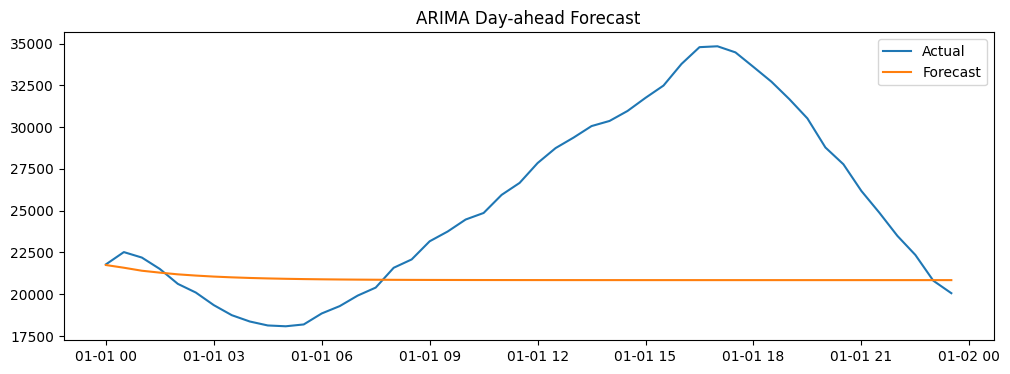

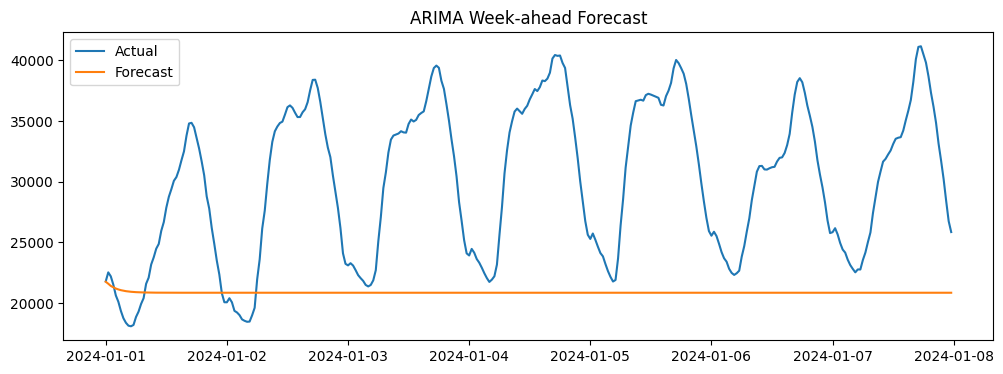

In [14]:
# FORECAST HORIZONS
# 3-hour data
# Day-ahead = 8 steps
# Week-ahead = 56 steps

day_steps = 48
week_steps = 336

forecast_day = model_fit.forecast(steps=day_steps)
forecast_week = model_fit.forecast(steps=week_steps)

# ACTUAL VALUES
actual_day = test_ts[:day_steps]
actual_week = test_ts[:week_steps]

# Evaluation
mae_day = np.mean(np.abs(actual_day.values - forecast_day.values))
mae_week = np.mean(np.abs(actual_week.values - forecast_week.values))

rmse_day = np.sqrt(np.mean((actual_day.values - forecast_day.values)**2))
rmse_week = np.sqrt(np.mean((actual_week.values - forecast_week.values)**2))

print("ARIMA Day-ahead MAE:", mae_day)
print("ARIMA Week-ahead MAE:", mae_week)

# Plot Day-ahead
plt.figure(figsize=(12,4))
plt.plot(actual_day.index, actual_day.values, label='Actual')
plt.plot(actual_day.index, forecast_day.values, label='Forecast')
plt.title("ARIMA Day-ahead Forecast")
plt.legend()
plt.show()

# Plot Week-ahead
plt.figure(figsize=(12,4))
plt.plot(actual_week.index, actual_week.values, label='Actual')
plt.plot(actual_week.index, forecast_week.values, label='Forecast')
plt.title("ARIMA Week-ahead Forecast")
plt.legend()
plt.show()


## Hyperparameter tuning

In [10]:
import itertools
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

p = [1,2]
d = [1]
q = [1,2]

best_mae = float("inf")
best_order = None

results = [] # Initializing an empty list to store all results

# 3-hour data
day_steps = 8
week_steps = 56

for order in itertools.product(p,d,q):
    try:
        model = ARIMA(train_ts, order=order)
        model_fit = model.fit()

        # Day-ahead forecast
        forecast_day = model_fit.forecast(steps=day_steps)
        actual_day = test_ts[:day_steps]

        mae_day = np.mean(np.abs(actual_day.values - forecast_day.values))

        # Week-ahead forecast
        forecast_week = model_fit.forecast(steps=week_steps)
        actual_week = test_ts[:week_steps]

        mae_week = np.mean(np.abs(actual_week.values - forecast_week.values))

        # Combine both
        mae = (mae_day + mae_week) / 2

        results.append({"config": order, "MAE": mae})

        if mae < best_mae:
            best_mae = mae
            best_order = order

    except:
        continue

print("Best ARIMA:", best_order, "MAE:", best_mae)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

Best ARIMA: (2, 1, 2) MAE: 2833.9578720934283


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [15]:
import pandas as pd

df_results = pd.DataFrame(results, columns=["config", "MAE"])
df_results = df_results.sort_values("MAE")

print(df_results)

      config          MAE
3  (2, 1, 2)  2833.957872
1  (1, 1, 2)  2850.693453
0  (1, 1, 1)  2857.236895
2  (2, 1, 1)  3174.614881
